# 02 Modelado supervisado

Este notebook contiene el **modelado principal** del proyecto. Aquí se comparan varios modelos supervisados para predecir si un caso corresponde a un fallo APS o no. La comparación incluye un baseline simple, modelos lineales, SVM, árboles de decisión y métodos ensemble como Random Forest, Extra Trees, AdaBoost y Gradient Boosting.

El objetivo es seguir un protocolo experimental limpio y alineado. Cada modelo se evalúa mediante **GridSearchCV con validación cruzada de 5 folds usando solo train**. La selección del modelo principal se hace a partir de los resultados de CV, no a partir de test.

Este notebook es el núcleo experimental porque aquí se decide qué modelo se usará como referencia principal en el resto del proyecto. Esa decisión debe ser repetible y defendible. Por eso no se elige un modelo por intuición ni por mirar el resultado final de test.

La comparación cubre modelos con comportamientos distintos. Los modelos lineales sirven como referencia interpretable. SVM aporta una separación basada en margen. Los árboles y ensembles permiten capturar interacciones entre sensores. Gradient Boosting es especialmente razonable en datos tabulares con relaciones no lineales y variables de escala muy distinta.

**Test queda reservado para la comparativa final**, una vez que los modelos y sus hiperparámetros ya están fijados.

## Preparación

Esta celda carga librerías, funciones auxiliares y carpetas. También fija la semilla para que los resultados sean reproducibles.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from project_utils import *

RANDOM_STATE = 42
crear_carpetas(".")
sns.set_theme(style="whitegrid")

El entorno queda listo para el modelado supervisado. La semilla fija y las rutas comunes ayudan a que el experimento pueda repetirse en otra ejecución.

## Datos, CV y métricas

Esta sección carga los datos procesados de train y test. Train se usa para ajustar hiperparámetros y seleccionar el modelo principal. Test se carga en el notebook porque será necesario al final, pero no participa en ninguna decisión de entrenamiento.

La validación cruzada se define con 5 folds estratificados. Esto significa que train se divide en 5 partes intentando mantener en cada una una proporción parecida de casos negativos y positivos. En este proyecto es importante porque la clase positiva es minoritaria y representa los fallos APS.

Si los folds no fueran estratificados, podría ocurrir que alguna partición tuviera muy pocos positivos. En ese caso, métricas como recall positivo, F1 positivo o PR-AUC serían menos estables y podrían dar una imagen poco representativa del rendimiento real del modelo.

Las métricas se eligen teniendo en cuenta el desbalanceo. **PR-AUC** se usa como métrica principal porque evalúa mejor el comportamiento sobre la clase positiva cuando hay pocos positivos. **Recall positivo** mide cuántos fallos APS se detectan. **F1 positivo** resume el equilibrio entre precisión y recall. **Balanced accuracy** ayuda a que la clase negativa no domine toda la evaluación.

La imputación y el escalado se colocan dentro de los **Pipeline**. Esto evita fuga de información, ya que cada fold aprende sus transformaciones solo con su parte de entrenamiento. Test tampoco participa en estos cálculos y queda reservado para la evaluación final.

In [ ]:
from time import time
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingClassifier

train_df = cargar_csv("data/processed/train.csv")
test_df = cargar_csv("data/processed/test.csv")
X_train, y_train = separar_x_y(train_df)
X_test, y_test = separar_x_y(test_df)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "recall_pos": make_scorer(recall_score, pos_label=1, zero_division=0),
    "f1_pos": make_scorer(f1_score, pos_label=1, zero_division=0),
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
}

Las métricas reflejan el problema de desbalanceo. PR-AUC se usa como métrica principal porque evalúa la clase positiva en un escenario con pocos positivos. Recall y F1 ayudan a interpretar la detección de fallos APS. Balanced accuracy evita que la clase negativa domine toda la lectura.

La imputación y el escalado se colocarán dentro de los Pipelines. Así cada transformación se aprende solo con los datos de entrenamiento de cada fold y se evita fuga de información.

## Búsqueda de hiperparámetros

Esta sección define el baseline y los modelos supervisados que se van a comparar. El baseline permite medir qué ocurre con una estrategia muy simple. Su función es comprobar si los modelos realmente aprenden patrones útiles o si solo aprovechan el desbalanceo de clases.

Las decisiones tomadas en el EDA se aplican aquí dentro de los **Pipeline**. Como el dataset tiene muchos valores faltantes, todos los modelos incluyen **SimpleImputer(strategy="median")**. La mediana es adecuada porque las variables tienen distribuciones asimétricas y valores extremos. Así se evita que la imputación dependa de valores muy alejados.

El EDA también mostró que las variables tienen escalas muy diferentes. Por eso los modelos sensibles a la escala, como regresión logística y SVM lineal, incluyen **StandardScaler**. Los modelos basados en árboles no necesitan escalado de la misma forma, por lo que se entrenan con imputación pero sin estandarización.

Esta organización evita fuga de información. La imputación y el escalado no se calculan antes de la validación cruzada usando todo train. Al estar dentro del **Pipeline**, cada fold aprende sus medianas y sus parámetros de escalado solo con la parte de entrenamiento correspondiente.

La comparación incluye varias familias de modelos. Se usa un baseline, modelos lineales, SVM, árboles individuales y métodos ensemble como Random Forest, Extra Trees, AdaBoost y HistGradientBoosting. Esto permite comparar modelos simples e interpretables con modelos más flexibles capaces de capturar relaciones no lineales entre sensores.

La búsqueda de hiperparámetros se realiza con **GridSearchCV y 5-fold CV**. Cada modelo prueba varias configuraciones usando solo train. La métrica principal de selección es **average precision**, porque el problema está muy desbalanceado y la clase positiva es la más importante.

Después de elegir la mejor configuración, **GridSearchCV** usa **refit="average_precision"** para reentrenar automáticamente el mejor modelo con todo train. Test no aparece en esta celda y no participa ni en la selección de hiperparámetros ni en la selección del modelo.

In [ ]:
modelos = {
    "dummy": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DummyClassifier())]), {"model__strategy": ["most_frequent", "stratified"]}),
    "logistic_regression": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]), {"model__C": [0.1, 1, 10], "model__class_weight": [None, "balanced"]}),
    "linear_svm": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LinearSVC(max_iter=5000, random_state=RANDOM_STATE, dual="auto"))]), {"model__C": [0.1, 1], "model__class_weight": [None, "balanced"]}),
    "decision_tree": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))]), {"model__max_depth": [5, 10, None], "model__min_samples_leaf": [1, 10], "model__class_weight": [None, "balanced"]}),
    "random_forest": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]), {"model__n_estimators": [100], "model__max_depth": [None, 15], "model__min_samples_leaf": [1, 5], "model__class_weight": [None, "balanced"]}),
    "extra_trees": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1))]), {"model__n_estimators": [100], "model__max_depth": [None, 15], "model__min_samples_leaf": [1, 5], "model__class_weight": [None, "balanced"]}),
    "adaboost": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=RANDOM_STATE))]), {"model__n_estimators": [50, 100], "model__learning_rate": [0.5, 1.0]}),
    "hist_gradient_boosting": (Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]), {"model__max_iter": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_leaf_nodes": [15, 31]}),
}

cv_rows = []
best_params = {}
best_estimators = {}
for nombre, (pipe, params) in modelos.items():
    print("Entrenando", nombre)
    t0 = time()
    grid = GridSearchCV(pipe, params, cv=cv, scoring=scoring, refit="average_precision", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_estimators[nombre] = grid.best_estimator_
    best_params[nombre] = grid.best_params_
    cv_rows.append({
        "modelo": nombre,
        "cv_average_precision": grid.cv_results_["mean_test_average_precision"][grid.best_index_],
        "cv_recall_pos": grid.cv_results_["mean_test_recall_pos"][grid.best_index_],
        "cv_f1_pos": grid.cv_results_["mean_test_f1_pos"][grid.best_index_],
        "cv_balanced_accuracy": grid.cv_results_["mean_test_balanced_accuracy"][grid.best_index_],
        "cv_roc_auc": grid.cv_results_["mean_test_roc_auc"][grid.best_index_],
        "fit_time_seconds": time() - t0,
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_average_precision", ascending=False)
cv_results.to_csv("artifacts/metrics/cv_model_selection.csv", index=False)
guardar_json(best_params, "artifacts/metrics/best_params.json")
cv_results

Entrenando dummy
Entrenando logistic_regression
Entrenando linear_svm
Entrenando decision_tree
Entrenando random_forest
Entrenando extra_trees
Entrenando adaboost
Entrenando hist_gradient_boosting


  File "c:\Users\mauro\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\mauro\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,modelo,cv_average_precision,cv_recall_pos,cv_f1_pos,cv_balanced_accuracy,cv_roc_auc,fit_time_seconds
7,hist_gradient_boosting,0.881018,0.738,0.808990,0.868271,0.988677,35.935041
4,random_forest,0.873611,0.697,0.787029,0.847873,0.984106,145.524574
5,extra_trees,0.865174,0.702,0.793397,0.850441,0.982762,34.198958
6,adaboost,0.793578,0.665,0.730155,0.831169,0.986368,172.306933
1,logistic_regression,0.771570,0.632,0.707529,0.814695,0.969706,31.282953
2,linear_svm,0.769416,0.619,0.708084,0.808407,0.958251,1328.046435
3,decision_tree,0.705539,0.639,0.697723,0.817881,0.919367,49.952865
0,dummy,0.016834,0.021,0.020679,0.502017,0.501000,5.031842


La tabla de validación cruzada muestra una mejora clara frente al baseline. El modelo dummy obtiene una **PR-AUC cercana a 0.017** y un **recall positivo cercano a 0.021**. Esto confirma que una estrategia simple casi no detecta fallos APS y que el problema no puede resolverse aprovechando solo la clase mayoritaria.

El mejor resultado de CV lo obtiene **hist_gradient_boosting**, con una **PR-AUC media cercana a 0.881**. También destacan **random_forest** y **extra_trees**, que obtienen resultados altos y muestran que los métodos basados en árboles funcionan bien en este dataset. Los modelos lineales y SVM mejoran mucho al baseline, pero quedan por debajo de los ensembles.

El tiempo de entrenamiento también es una parte importante de la comparación. No basta con mirar solo la métrica principal, porque dos modelos pueden tener rendimientos parecidos y costes computacionales muy distintos. **hist_gradient_boosting** obtiene el mejor rendimiento y tarda unos **36 segundos**. En cambio, **random_forest** consigue un resultado bastante cercano, con una **PR-AUC cercana a 0.874**, pero tarda unos **146 segundos**. Esto significa que Random Forest es competitivo, aunque en este experimento necesita bastante más tiempo para quedar ligeramente por debajo de HGB.

También aparece el caso contrario. **linear_svm** tarda unos **1328 segundos** y obtiene una **PR-AUC cercana a 0.769**, por debajo de los mejores modelos y similar a logistic regression. Esto lo hace poco atractivo en este proyecto, porque consume mucho tiempo y no aporta una mejora clara. **adaboost** también tarda bastante, unos **172 segundos**, y queda por debajo de los principales ensembles en PR-AUC, recall y F1.

Esta comparación muestra que el mejor modelo no debe elegirse solo por rendimiento, sino también por eficiencia y estabilidad práctica. En este caso, **hist_gradient_boosting** ofrece el mejor equilibrio entre calidad predictiva y tiempo de entrenamiento. **extra_trees** también es interesante porque tarda unos **34 segundos** y mantiene un rendimiento alto, aunque algo inferior al modelo seleccionado.

La selección del modelo principal se hace únicamente con los resultados de CV sobre train. Test no interviene en esta decisión. Por tanto, **hist_gradient_boosting** queda fijado como modelo principal antes de consultar la evaluación final en test.

La métrica usada para seleccionar es **average precision**, equivalente a PR-AUC. Esta elección es adecuada porque la clase positiva es muy minoritaria y el objetivo principal es detectar fallos APS. En este contexto, una métrica centrada en la recuperación de positivos es más informativa que accuracy.

## Selección del modelo principal

Esta celda identifica el modelo con mayor **PR-AUC media en validación cruzada**. La decisión se toma usando solo los resultados de CV sobre train.

Este paso es clave para cumplir el protocolo experimental. El modelo principal debe quedar fijado antes de consultar test. Así se evita que la partición final influya en la selección del modelo, en los hiperparámetros o en la estrategia experimental.

In [ ]:
selected_name = cv_results.iloc[0]["modelo"]
selected_model = best_estimators[selected_name]
selected_info = {
    "selected_model": selected_name,
    "selection_metric": "cv_average_precision",
    "selection_value": float(cv_results.iloc[0]["cv_average_precision"]),
    "note": "Seleccionado solo con CV en train",
}
guardar_json(selected_info, "artifacts/metrics/selected_model_by_cv.json")
selected_info

{'selected_model': 'hist_gradient_boosting',
 'selection_metric': 'cv_average_precision',
 'selection_value': 0.8810180976180211,
 'note': 'Seleccionado solo con CV en train'}

El modelo principal seleccionado es **hist_gradient_boosting**, con una **PR-AUC media de 0.881** en validación cruzada.

**HistGradientBoosting** es una implementación de Gradient Boosting en scikit-learn. Pertenece a la familia de modelos de boosting, que combinan modelos simples de forma secuencial para corregir errores anteriores. Es una opción bastante buena en datos tabulares porque suele capturar relaciones no lineales e interacciones entre variables.

## Comparativa final en test

Esta sección evalúa en test los modelos ya ajustados mediante **GridSearchCV**. En este punto, los hiperparámetros y el modelo principal ya están fijados usando train. Por tanto, la tabla de test funciona como comparativa final y no modifica ninguna decisión anterior.

Separar CV y test es importante. La validación cruzada estima el rendimiento durante la fase de selección. Test mide una única vez cómo se comportan los modelos fijados sobre datos reservados. Esta separación es la base del criterio indicado por el profesor.

In [ ]:
test_rows = []
for nombre, modelo in best_estimators.items():
    test_rows.append(evaluar_modelo(nombre, modelo, X_test, y_test))

test_results = crear_resumen_resultados(test_rows)
orden_cv = {nombre: i for i, nombre in enumerate(cv_results["modelo"].tolist())}
test_results["orden_cv"] = test_results["modelo"].map(orden_cv)
test_results = test_results.sort_values("orden_cv").drop(columns=["orden_cv"])
test_results.to_csv("artifacts/metrics/model_test_results.csv", index=False)
guardar_modelo(selected_model, "artifacts/models/best_model.joblib")
test_results

,modelo,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,tn,fp,fn,tp,coste
7,hist_gradient_boosting,0.993375,0.875584,0.955932,0.752000,0.841791,0.996043,0.922450,15612,13,93,282,46630
4,random_forest,0.992437,0.858187,0.947183,0.717333,0.816388,0.992745,0.920230,15610,15,106,269,53150
5,extra_trees,0.992000,0.851456,0.939502,0.704000,0.804878,0.993318,0.917604,15608,17,111,264,55670
6,adaboost,0.989563,0.838496,0.844371,0.680000,0.753323,0.985479,0.839581,15578,47,120,255,60470
1,logistic_regression,0.990000,0.849131,0.845659,0.701333,0.766764,0.978664,0.819209,15577,48,112,263,56480
2,linear_svm,0.989688,0.821643,0.883212,0.645333,0.745763,0.967563,0.821631,15593,32,133,242,66820
3,decision_tree,0.989812,0.821707,0.889706,0.645333,0.748068,0.948364,0.769639,15595,30,133,242,66800
0,dummy,0.959937,0.499296,0.021583,0.016000,0.018377,0.502283,0.023570,15353,272,369,6,187220


En test, **hist_gradient_boosting** mantiene un comportamiento fuerte. Obtiene una **PR-AUC cercana a 0.922**, un **F1 positivo cercano a 0.842** y un **recall positivo cercano a 0.752**. La matriz de confusión muestra **282 verdaderos positivos**, **13 falsos positivos** y **93 falsos negativos**.

El resultado es coherente con la validación cruzada. El modelo seleccionado por CV sigue entre los mejores en test y mantiene una mejora clara frente al baseline. Esto indica que la señal aprendida en train generaliza de forma razonable a la partición reservada.

El baseline vuelve a mostrar por qué accuracy no es suficiente. Aunque obtiene una accuracy de **0.960**, solo detecta **6** de los **375** fallos APS de test. Su **recall positivo es 0.016**, por lo que casi todos los fallos reales quedan sin detectar.

La comparación también muestra que el modelo no es perfecto. **hist_gradient_boosting** deja **93 falsos negativos**, que en este problema representan fallos APS no detectados. Esto es importante porque un falso negativo tiene un coste alto en mantenimiento. Por tanto, el modelo es claramente útil frente al baseline, pero debe analizarse junto con el coste y los errores.

La tabla de test no cambia la selección del modelo principal. Solo permite comprobar el rendimiento final de los modelos ya fijados.

## Matriz de confusión

Esta figura muestra la matriz de confusión del modelo seleccionado por CV. Se calcula en test solo después de que el modelo ya ha quedado fijado con validación cruzada sobre train.

La matriz permite traducir las métricas a errores concretos. En este problema, un falso positivo implica revisar un camión que no tenía fallo APS. Un falso negativo implica no detectar un fallo APS real. Por eso los falsos negativos son especialmente importantes desde el punto de vista operativo.

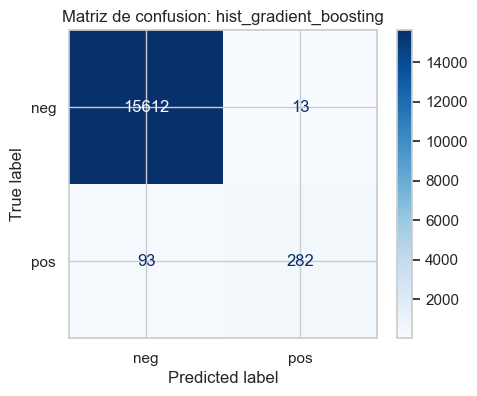

In [ ]:
y_pred = selected_model.predict(X_test)
classification_report_dataframe(y_test, y_pred).to_csv("artifacts/metrics/classification_report_test.csv")
cm = calcular_matriz_confusion(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["neg", "pos"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Matriz de confusion: {selected_name}")
guardar_figura(fig, "artifacts/figures/confusion_matrix_best_model.png")
plt.show()

La matriz de confusión muestra **282 verdaderos positivos**, **15612 verdaderos negativos**, **13 falsos positivos** y **93 falsos negativos**.

El número de falsos positivos es bajo, lo que indica que el modelo no genera muchas alarmas innecesarias. Sin embargo, los **93 falsos negativos** siguen siendo relevantes porque representan fallos APS no detectados. En mantenimiento predictivo, este tipo de error puede tener un coste alto.

El modelo funciona claramente mejor que el baseline, pero no elimina todos los errores importantes. Esta lectura justifica que el proyecto no se quede solo en PR-AUC o F1. También es necesario estudiar el coste asimétrico y analizar los errores con más detalle.

La matriz ayuda a interpretar el problema en términos operativos. PR-AUC resume la capacidad del modelo para ordenar positivos, pero la matriz muestra cuántos fallos se detectan y cuántos se escapan. Esa diferencia será importante en el análisis de coste del siguiente notebook.

## Lectura del modelado principal

Los modelos se comparan con **GridSearchCV**, se usa **5-fold CV**, la selección se hace solo con **train** y test queda reservado para la evaluación final.

El resultado principal es defendible. El baseline falla en la clase positiva y los modelos avanzados mejoran de forma clara. **hist_gradient_boosting** se selecciona como modelo principal porque obtiene la mejor PR-AUC media en validación cruzada sobre train.

La conclusión del notebook no es solo que un modelo gana. La conclusión metodológica es que el proyecto sigue un protocolo limpio. Primero se define una métrica principal. Después se comparan configuraciones con CV en train. Luego se fija el modelo principal. Finalmente se evalúa en test una sola vez.

Esta estructura reduce el riesgo de fuga de información y hace que la comparativa final sea defendible. Aun así, la matriz de confusión muestra que siguen existiendo falsos negativos. Por eso el siguiente paso es estudiar si la métrica de selección y el coste operativo cuentan la misma historia.